# 04 -- Why symmetry *is* the architecture

**The physics symmetries are the inductive bias. Build them in and you need far less data.**

In Notebook 03 we used sorted pairwise distances as features. That was a quick fix with three real weaknesses, which we make concrete below. The principled cure is to build the symmetries and the locality of physics directly into the representation.

The three symmetries every atomic potential must have:

1. **Translation invariance** -- shifting all atoms does not change the energy.
2. **Rotation invariance** -- rotating the whole system does not change the energy.
3. **Permutation invariance** -- swapping two identical atoms does not change the energy.

Behler and Parrinello (2007) introduced **symmetry functions** that satisfy all three, are smooth, are local (they use a cutoff), and -- crucially for real chemistry -- encode **angular** information that pairwise distances alone cannot. In this notebook we implement them from scratch and show they improve data efficiency over raw distances.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from afs.md import (
    lj_energy, lj_forces, triangular_lattice,
    disk_cluster, thermal_velocities, run_md,
)

torch.manual_seed(0)
np.random.seed(0)

## 1. What sorted distances get right -- and where they fail

Sorted pairwise distances (Notebook 03) are genuinely translation-, rotation-, and permutation-invariant. Let us confirm the permutation part, then expose the three problems that motivate a better representation.

In [2]:
def sorted_distances(pos):
    n = len(pos)
    dists = [np.linalg.norm(pos[i] - pos[j])
             for i in range(n) for j in range(i + 1, n)]
    return np.sort(dists)

rng = np.random.default_rng(0)
pos = triangular_lattice(3, 3) + 0.1 * rng.standard_normal((9, 2))

# (Good property) Permutation invariance: relabel the atoms -> identical feature vector
perm = rng.permutation(9)
print('Permutation-invariant:', np.allclose(sorted_distances(pos), sorted_distances(pos[perm])))

Permutation-invariant: True


**Problem 1 -- non-smoothness.** Sorting introduces kinks: as an atom moves, two distances can cross and swap places in the sorted vector. At that point the feature has a corner, so its derivative jumps -- and forces are derivatives. Kinky features make force learning harder. Watch a few components of the sorted-distance vector as we slide one atom along a line.

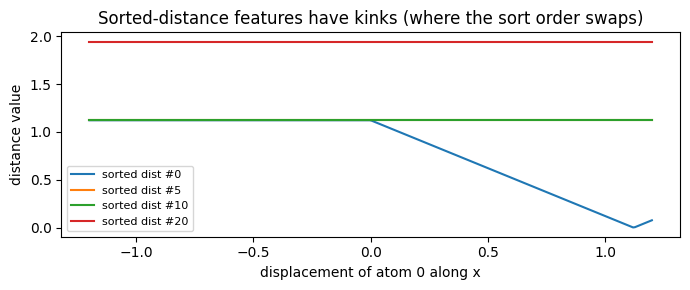

Each corner is a point where two distances cross and swap slots -- a discontinuous
derivative. Smooth symmetry functions (below) avoid this.


In [3]:
base = triangular_lattice(3, 3)
shifts = np.linspace(-1.2, 1.2, 300)
comps = np.array([sorted_distances(base + np.array([[s, 0.0]] + [[0, 0]] * 8)) for s in shifts])

plt.figure(figsize=(7, 3))
for c in [0, 5, 10, 20]:
    plt.plot(shifts, comps[:, c], lw=1.5, label=f'sorted dist #{c}')
plt.xlabel('displacement of atom 0 along x'); plt.ylabel('distance value')
plt.title('Sorted-distance features have kinks (where the sort order swaps)')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()
print('Each corner is a point where two distances cross and swap slots -- a discontinuous')
print('derivative. Smooth symmetry functions (below) avoid this.')

**Problem 2 -- no locality.** The sorted-distance vector has length $N(N-1)/2$: it grows as $N^2$ and mixes every pair, near and far. Real potentials are *local* -- an atom only feels its neighbours within a cutoff -- which keeps cost $O(N)$ and makes the model transferable across system sizes.

**Problem 3 -- no angular information.** For a genuine many-body potential (real chemistry, DFT), the energy depends on bond *angles*, not just distances. Two local environments can share a distance distribution yet differ in their angles. Pairwise distances cannot see that; the angular symmetry functions below can.

> (For the Lennard-Jones toy target, whose energy is literally a sum over pair distances, distances are in principle sufficient -- so here the payoff of symmetry functions shows up as smoothness and data efficiency. On real many-body data, angular terms become *necessary*.)

## 2. Behler-Parrinello symmetry functions

The Behler-Parrinello (BP) approach represents the local environment of atom $i$ by a fingerprint built from two kinds of functions:

**Radial** (how many neighbours at each distance):
$$G^{rad}_{i,\mu} = \sum_{j \neq i} e^{-\eta (r_{ij} - r_s)^2} \, f_c(r_{ij})$$

**Angular** (which angles are present):
$$G^{ang}_{i,\mu} = 2^{1-\zeta} \sum_{j,k \neq i} (1 + \lambda \cos\theta_{ijk})^\zeta \, e^{-\eta (r_{ij}^2 + r_{ik}^2 + r_{jk}^2)} \, f_c(r_{ij}) f_c(r_{ik}) f_c(r_{jk})$$

with a smooth cutoff $f_c(r) = 0.5[\cos(\pi r / r_c) + 1]$ for $r < r_c$, else 0.

These are translation-, rotation-, and permutation-invariant, **smooth** (the cutoff and Gaussians have continuous derivatives), **local** (the cutoff), and carry **angular** information -- fixing all three problems above.

In [4]:
def cutoff(r, r_cut=3.5):
    """Cosine cutoff: smooth to zero at r_cut."""
    return np.where(r < r_cut, 0.5 * (np.cos(np.pi * r / r_cut) + 1.0), 0.0)

def g2_radial(pos, r_cut=3.5, eta_list=None, rs_list=None):
    """Radial symmetry functions for all atoms. Returns (N, n_eta*n_rs)."""
    if eta_list is None:
        eta_list = [0.5, 1.0, 2.0, 4.0]
    if rs_list is None:
        rs_list = [0.0, 0.5, 1.0, 1.5, 2.0]
    n = len(pos)
    feats = []
    for i in range(n):
        row = []
        for eta in eta_list:
            for rs in rs_list:
                G = 0.0
                for j in range(n):
                    if j == i:
                        continue
                    rij = np.linalg.norm(pos[i] - pos[j])
                    G += np.exp(-eta * (rij - rs) ** 2) * cutoff(rij, r_cut)
                row.append(G)
        feats.append(row)
    return np.array(feats)

def g4_angular(pos, r_cut=3.5, eta=0.5, zeta_list=None, lam_list=None):
    """Angular symmetry functions (simplified G4) for all atoms. Returns (N, n_zeta*n_lam)."""
    if zeta_list is None:
        zeta_list = [1.0, 4.0]
    if lam_list is None:
        lam_list = [-1.0, 1.0]
    n = len(pos)
    feats = []
    for i in range(n):
        row = []
        for zeta in zeta_list:
            for lam in lam_list:
                G = 0.0
                for j in range(n):
                    if j == i:
                        continue
                    for k in range(n):
                        if k == i or k <= j:
                            continue
                        rij_vec = pos[j] - pos[i]
                        rik_vec = pos[k] - pos[i]
                        rij = np.linalg.norm(rij_vec)
                        rik = np.linalg.norm(rik_vec)
                        rjk = np.linalg.norm(pos[j] - pos[k])
                        cos_theta = np.dot(rij_vec, rik_vec) / (rij * rik + 1e-12)
                        G += (2 ** (1 - zeta)
                              * (1 + lam * cos_theta) ** zeta
                              * np.exp(-eta * (rij ** 2 + rik ** 2 + rjk ** 2))
                              * cutoff(rij, r_cut) * cutoff(rik, r_cut) * cutoff(rjk, r_cut))
                row.append(G)
        feats.append(row)
    return np.array(feats)

def bp_features(pos):
    """Concatenate radial + angular features per atom, then sum over atoms."""
    per_atom = np.concatenate([g2_radial(pos), g4_angular(pos)], axis=1)
    return per_atom.sum(axis=0)

# BP features are invariant to translation and rotation
p = triangular_lattice(3, 3) + 0.1 * rng.standard_normal((9, 2))
feat = bp_features(p)
feat_shifted = bp_features(p + np.array([10.0, 5.0]))
theta = np.pi / 3
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
feat_rotated = bp_features((R @ p.T).T)
print(f'BP feature length: {len(feat)}')
print('Translation-invariant:', np.allclose(feat, feat_shifted, atol=1e-6))
print('Rotation-invariant:   ', np.allclose(feat, feat_rotated, atol=1e-5))
print('Permutation-invariant:', np.allclose(feat, bp_features(p[rng.permutation(9)]), atol=1e-6))

BP feature length: 24
Translation-invariant: True
Rotation-invariant:    True
Permutation-invariant: True


## 3. Train a BP-featured network and compare to raw distances

Now we train two networks on the same dataset -- one on sorted pairwise distances (Notebook 03), one on BP symmetry functions -- and sweep the training-set size to measure data efficiency.

In [5]:
def make_dataset_bp(n_samples=800, noise=0.3):
    base = triangular_lattice(3, 3)
    rng = np.random.default_rng(42)
    X_dist, X_bp, Y = [], [], []
    while len(Y) < n_samples:
        pos = base + noise * rng.standard_normal(base.shape)
        E = lj_energy(pos)
        if abs(E) > 50:
            continue
        X_dist.append(sorted_distances(pos))
        X_bp.append(bp_features(pos))
        Y.append(E)
    return np.array(X_dist), np.array(X_bp), np.array(Y)

print('Generating dataset (this takes ~30 s)...')
X_dist, X_bp, Y = make_dataset_bp(n_samples=800)
print(f'Dataset: {len(Y)} configs, dist features: {X_dist.shape[1]}, BP features: {X_bp.shape[1]}')

Generating dataset (this takes ~30 s)...


Dataset: 800 configs, dist features: 36, BP features: 24


n_train=  50  dist RMSE=18.6691  BP RMSE=12.5889


n_train= 100  dist RMSE=18.3723  BP RMSE=12.4421


n_train= 200  dist RMSE=18.4227  BP RMSE=11.8011


n_train= 400  dist RMSE=18.3773  BP RMSE=14.3372


n_train= 600  dist RMSE=18.4259  BP RMSE=13.4241


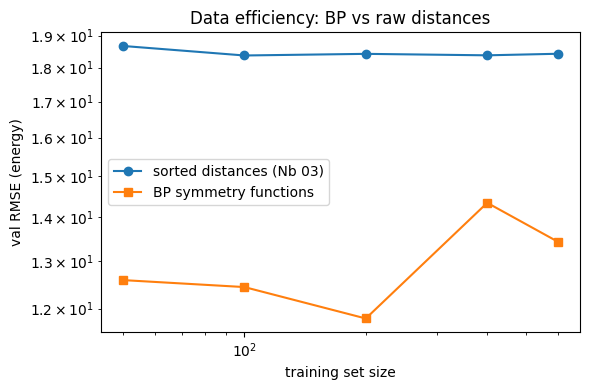

In [6]:
def train_net(X_tr, y_tr, X_va, y_va, hidden=64, epochs=300, lr=3e-3):
    model = nn.Sequential(
        nn.Linear(X_tr.shape[1], hidden), nn.SiLU(),
        nn.Linear(hidden, hidden), nn.SiLU(),
        nn.Linear(hidden, 1),
    )
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    Xtr = torch.tensor(X_tr, dtype=torch.float32); ytr = torch.tensor(y_tr, dtype=torch.float32)
    Xva = torch.tensor(X_va, dtype=torch.float32); yva = torch.tensor(y_va, dtype=torch.float32)
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss = nn.functional.mse_loss(model(Xtr).squeeze(), ytr)
        loss.backward(); opt.step(); sched.step()
    model.eval()
    with torch.no_grad():
        return nn.functional.mse_loss(model(Xva).squeeze(), yva).item() ** 0.5

train_sizes = [50, 100, 200, 400, 600]
n_val = 150
val_i = np.arange(len(Y) - n_val, len(Y))
rmse_dist, rmse_bp = [], []
for n_tr in train_sizes:
    tr_i = np.arange(n_tr)
    rd = train_net(X_dist[tr_i], Y[tr_i], X_dist[val_i], Y[val_i])
    rb = train_net(X_bp[tr_i], Y[tr_i], X_bp[val_i], Y[val_i])
    rmse_dist.append(rd); rmse_bp.append(rb)
    print(f'n_train={n_tr:4d}  dist RMSE={rd:.4f}  BP RMSE={rb:.4f}')

plt.figure(figsize=(6, 4))
plt.loglog(train_sizes, rmse_dist, 'o-', label='sorted distances (Nb 03)')
plt.loglog(train_sizes, rmse_bp, 's-', label='BP symmetry functions')
plt.xlabel('training set size'); plt.ylabel('val RMSE (energy)')
plt.title('Data efficiency: BP vs raw distances')
plt.legend(); plt.tight_layout(); plt.show()

## 4. What symmetry buys you

By encoding what we know about the physics (symmetries, locality, smoothness) in the representation, the network only has to learn what the physics does *not* hand us -- the shape of the energy surface. This is the heart of modern ML for science:

> The best ML models for physics are not the most flexible ones. They are the ones that encode the right physical constraints.

**Radial functions** are Gaussian probes: the feature counts how many atoms sit in each distance band -- a density fingerprint. **Angular functions** add a bond-angle fingerprint that breaks the degeneracy between different bonding geometries.

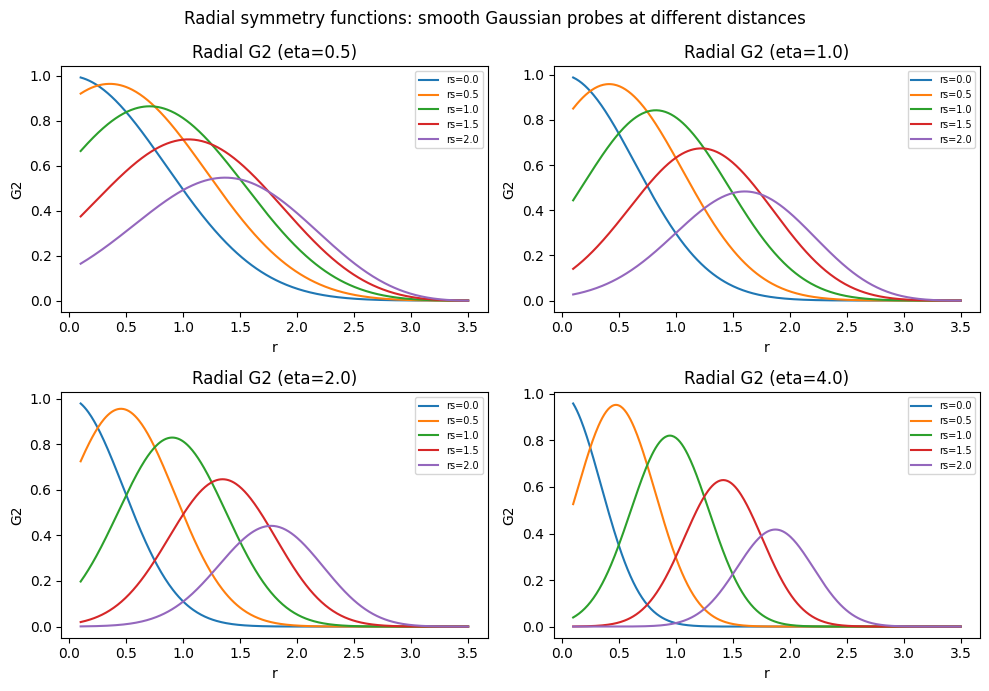

In [7]:
r_vals = np.linspace(0.1, 3.5, 400)
eta_list = [0.5, 1.0, 2.0, 4.0]
rs_list = [0.0, 0.5, 1.0, 1.5, 2.0]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, eta in zip(axes.flat, eta_list):
    for rs in rs_list:
        G = np.exp(-eta * (r_vals - rs) ** 2) * cutoff(r_vals)
        ax.plot(r_vals, G, lw=1.5, label=f'rs={rs}')
    ax.set_title(f'Radial G2 (eta={eta})')
    ax.set_xlabel('r'); ax.set_ylabel('G2'); ax.legend(fontsize=7)
plt.suptitle('Radial symmetry functions: smooth Gaussian probes at different distances', fontsize=12)
plt.tight_layout(); plt.show()

## 5. What comes next

BP symmetry functions solve the symmetry problem elegantly but have two remaining issues:

1. **Hand-designed features.** The radial and angular functions are chosen by hand and may    miss important structure.
2. **Not end-to-end trainable.** The features are fixed before training; the network cannot    adapt the representation to the data.

The fix is **graph neural networks** (GNNs): instead of fixed symmetry functions, the network learns its own atom representations by passing messages along the bonds of the molecular graph. Each atom aggregates information from its neighbours -- exactly what the BP sum does, but now the aggregation is itself learned. That is Notebook 05.

### Exercises

1. **More features.** Add more $(\eta, r_s)$ pairs to the radial functions. When does adding    more stop helping?

2. **Per-atom energies.** In BP, $E = \sum_i E_i(\mathbf{G}_i)$. Implement this: one network    mapping the per-atom feature $\mathbf{G}_i$ to a per-atom energy $E_i$, then sum. This is    more physical and scales to large systems.

3. **Forces via autograd.** Implement `bp_features_torch` in PyTorch keeping the graph, and    verify `torch.autograd` gives forces consistent with finite differences (as in Notebook 03).